# **CatBoost - REGRESSOR**
> **CatBoost** is a gradient boosting library specifically optimized for **Categorical** feature handling in both **Classification** and **Regression** tasks.

> Known for **high accuracy**, **speed**, and **robustness** to overfitting.

> Tips: Leverage **Cross Validation** for **optimal performance**.

### **General Recommendation:**
  - `For classification:` Start with **XGBoost** or **LightGBM**.
  - `For Classification [categorical feature and imbalanced dataset] Without Pre-processing data:` **CatBoost** 
  - `For regression:` **LightGBM** or **XGBoost** is highly recommended.

<br>

---

<br>

## 1. What is CatBoost?
- **CatBoost** (Categorical Boosting) is a gradient boosting library developed by **Yandex** designed to handle categorical features efficiently.
- It handles **categorical variables** internally without the need for extensive preprocessing like **one-hot encoding**.
- Commonly used in supervised learning tasks such as regression and classification.

<br>

---

<br>

## 2. Key Features
- **Boosting Framework**: Builds an ensemble of decision trees to improve predictive accuracy.
- **Efficient Handling of Categorical Features**: Automatically handles categorical features without preprocessing.
- **Ordered Boosting**: Mitigates overfitting by using ordered boosting in training.
- **Speed and Accuracy**: Optimized for speed without compromising on accuracy.
- **Cross-Platform Support**: Available in Python, R, C++, and other languages.

<br>

---

<br>

## 3. Common Regression Objectives in CatBoost

<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif;">
  <thead>
    <tr>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Objective</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Use Case</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Output</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><b>RMSE</b></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">For minimizing Root Mean Squared Error</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Continuous predictions (real values)</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><b>MAE</b></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">For minimizing Mean Absolute Error</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Continuous predictions (real values)</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><b>Huber</b></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">For robust regression tasks, sensitive to outliers</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Continuous predictions (real values)</td>
    </tr>
  </tbody>
</table>

<br>

---

<br>

## 4. Advantages
- **Handles Categorical Features**: Handles categorical features internally without the need for one-hot encoding.
- **High Speed**: Fast training due to efficient algorithms.
- **Less Overfitting**: Provides robust results by mitigating overfitting through its boosting technique.
- **Feature Importance**: Provides valuable insights into the importance of features.
- **Parallel and GPU Support**: Supports parallel computing and GPU acceleration for faster model training.

<br>

---

<br>

## ⭐ Things to Keep in Mind
- Ensure that **CatBoost** and **scikit-learn** versions are compatible.
- **Hyperparameter tuning** is crucial for **maximizing performance**.
- Be cautious of **overfitting** on smaller datasets; always use **cross-validation**.

<br>

---


In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings

In [2]:
df = pd.read_csv('/content/61_laptop_prices_data.csv')

In [3]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [4]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [5]:
df.shape

(1275, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [7]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [8]:
le = LabelEncoder()
df['Company'] = le.fit_transform(df['Company'])
df['Product'] = le.fit_transform(df['Product'])
df['TypeName'] = le.fit_transform(df['TypeName'])
df['OS'] = le.fit_transform(df['OS'])
df['Screen'] = le.fit_transform(df['Screen'])
df['Touchscreen'] = le.fit_transform(df['Touchscreen'])
df['IPSpanel'] = le.fit_transform(df['IPSpanel'])
df['RetinaDisplay'] = le.fit_transform(df['RetinaDisplay'])
df['CPU_company'] = le.fit_transform(df['CPU_company'])
df['CPU_model'] = le.fit_transform(df['CPU_model'])
df['PrimaryStorage'] = le.fit_transform(df['PrimaryStorage'])
df['SecondaryStorageType'] = le.fit_transform(df['SecondaryStorageType'])
df['PrimaryStorageType'] = le.fit_transform(df['PrimaryStorageType'])
df['GPU_company'] = le.fit_transform(df['GPU_company'])
df['GPU_model'] = le.fit_transform(df['GPU_model'])

In [9]:
X = df.drop(["Price_euros", "Product"], axis = 1)
Y = df['Price_euros']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
!pip install catboost

In [13]:
# import catboost
from catboost import CatBoostRegressor

> Hyperparameters for CatBoost Regressor

```python
model = CatBoostRegressor(
    # Model Hyperparameters
    objective='RMSE',                # Root Mean Squared Error for regression tasks (default)
    iterations=1000,                 # Number of boosting rounds (trees)
    depth=6,                         # Maximum depth of each tree
    learning_rate=0.1,               # Step size at each iteration while moving toward a minimum of the loss function
    subsample=0.8,                   # Fraction of samples used for each tree to prevent overfitting
    colsample_bylevel=0.8,           # Fraction of features used for each tree to prevent overfitting

    # Regularization Parameters
    l2_leaf_reg=3,                   # L2 regularization term on weights
    random_seed=42,                  # Seed for reproducibility

    # Tree Growth Parameters
    min_data_in_leaf=20,             # Minimum number of samples in a leaf node
)
```

<h3>Common <strong>Regression Objectives</strong> in CatBoost</h3>


<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif;">
  <thead>
    <tr>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Objective</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Use Case</th>
      <th style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 16px;">Output</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><b>RMSE</b></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">For minimizing Root Mean Squared Error</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Continuous predictions (real values)</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><b>MAE</b></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">For minimizing Mean Absolute Error</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Continuous predictions (real values)</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;"><b>Huber</b></td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">For robust regression tasks, sensitive to outliers</td>
      <td style="padding: 12px; border: 1px solid #ddd; text-align: center; font-size: 14px;">Continuous predictions (real values)</td>
    </tr>
  </tbody>
</table>

In [14]:
# Initialize CatBoost Regressor
model = CatBoostRegressor(objective='RMSE')

In [15]:
# Train the dataset with CatBoost Model
model.fit(X_train, y_train)

Learning rate set to 0.041071
0:	learn: 679.2444921	total: 49.7ms	remaining: 49.7s
1:	learn: 665.5865459	total: 52.6ms	remaining: 26.2s
2:	learn: 651.0466255	total: 55.8ms	remaining: 18.5s
3:	learn: 637.0094486	total: 57.7ms	remaining: 14.4s
4:	learn: 623.4232501	total: 60.7ms	remaining: 12.1s
5:	learn: 610.9012965	total: 63.7ms	remaining: 10.5s
6:	learn: 598.5472289	total: 66.9ms	remaining: 9.48s
7:	learn: 586.9866162	total: 70.2ms	remaining: 8.71s
8:	learn: 575.8063078	total: 73.4ms	remaining: 8.08s
9:	learn: 563.9690673	total: 76.7ms	remaining: 7.59s
10:	learn: 552.9704408	total: 78.9ms	remaining: 7.09s
11:	learn: 544.2516973	total: 82ms	remaining: 6.75s
12:	learn: 534.5656604	total: 84.8ms	remaining: 6.44s
13:	learn: 524.9550397	total: 90.9ms	remaining: 6.4s
14:	learn: 515.9730698	total: 94.5ms	remaining: 6.21s
15:	learn: 508.2289984	total: 96.5ms	remaining: 5.94s
16:	learn: 499.9935010	total: 100ms	remaining: 5.8s
17:	learn: 491.6569918	total: 102ms	remaining: 5.58s
18:	learn: 484

In [16]:
# Make predictions
y_pred = model.predict(X_test)

In [17]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [18]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error: 64867.65
R2 Score: 0.87


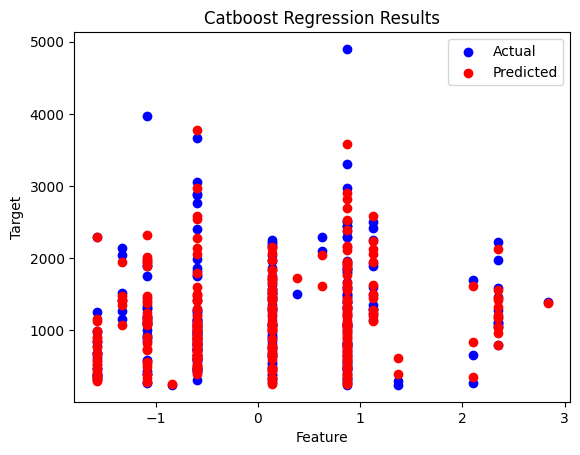

In [19]:
# Plot Result
import matplotlib.pyplot as plt

# Assuming X_test has multiple features, we'll plot against the first feature
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual')
plt.scatter(X_test[:, 0], y_pred, color='red', label='Predicted')
plt.legend()
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Catboost Regression Results')
plt.show()

In [20]:
# Display feature importance
feature_importances = model.get_feature_importance()
print("Feature Importances:", feature_importances)

Feature Importances: [3.96459597e+00 6.92144921e+00 4.08114515e+00 2.26800725e+01
 3.15087781e+00 1.34848460e+01 1.93142931e+00 4.25472914e+00
 2.84323576e+00 6.81638178e-01 1.55331712e+00 3.56828957e-03
 1.03876378e-01 9.74507498e+00 7.19292979e+00 3.39569306e+00
 9.18226572e-01 5.05377261e+00 5.06777966e-01 1.50460268e+00
 6.02814155e+00]
